In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import os
import json
from astropy.io import fits
import pandas as pd
from scipy.optimize import curve_fit
from itertools import combinations


In [3]:
WINDOWS_SIZE = 60           #Window size for sliding window correlation (in frames)
STEP_SIZE = 10              #Step size for sliding window correlation (in frames)
HZ = 5                     #Frequency of LED
EXPOSURE_TIME = 0.040       #units of seconds


#the effective readout rate is negligible because of frame transfer. 
# So our exposure time is effectively the frame time, which is 1/Hz. 
# So we can use this to estimate how many frames correspond to one period of the signal, which can help us 
#       choose appropriate window sizes for the sliding window correlation.

PERIOD = 1 / HZ             #Period of the LED signal in seconds

boxes_filepath = "./boxes.json"



#================================================================================
"""
Helper functions for FFT-based phase analysis of camera signals.
"""

"""
Linear model for curve fitting Phase Drift (Clock Drift) over time.
"""
def linear_model(x, a, b):
    return a * x + b

"""
Lists files in a directory, excluding subdirectories. 
If the directory does not exist, it raises an error.
"""
def list_files_classic(directory_path):
    '''
    List all files in a directory, excluding subdirectories.'''
    # Get all entries in the directory
    entries = os.listdir(directory_path)
    
    # Filter out directories to keep only files
    files = [f for f in entries if os.path.isfile(os.path.join(directory_path, f))]
    
    return files

"""
Load in FITS data from a given file path and return the data array.
"""
def load_data(file_path):
    hdul = fits.open(file_path)
    return hdul[0].data

"""
Calculate mean intensities within a specified box region for each frame in the FITS file.
"""
def cal_intensities(file, cam_id, box):
    data = load_data(file)
    xmin, xmax, ymin, ymax = box['xmin'], box['xmax'], box['ymin'], box['ymax']
    intensities = np.mean(data[:, ymin:ymax+1, xmin:xmax+1], axis=(1, 2))

    return intensities

"""
Confirm that a folder path exists; if it doesn't, create it
"""
def confirm_folder_path(folder_path):
    """Ensure that the folder exists; create it if it doesn't."""
    if os.path.exists(folder_path):
        if os.path.isdir(folder_path):
            pass
    else:
        os.makedirs(folder_path, exist_ok=True)
        print(f"The folder '{folder_path}' has been created.")
 
"""
Perform a sub frame estimation of cross correltaion peak.
"""
def subframe_peak_location(correlation):
    """
    Refines peak location using parabolic interpolation
    to achieve sub-frame accuracy.

    Parabolic interpolation is used because the peaks from the cross correltaion are shaped
    like a parabola. By fitting a parabola to the peak and its immediate neighbors,
    we can estimate the true peak location.
    """
    peak = np.argmax(correlation)

    # Ensure peak is not at edge
    if 1 <= peak < len(correlation) - 1:

        y0 = correlation[peak - 1]
        y1 = correlation[peak]
        y2 = correlation[peak + 1]

        denom = 2 * (2*y1 - y0 - y2)

        if denom != 0:
            delta = (y0 - y2) / denom
            peak = peak + delta

    return peak

def sliding_window_correlation(main_sig, other_sig, window_size=60, step=10, main_camera_id=None, other_camera_id=None, plot=True, save_path=None, file_name=None):
    """
    Performs cross-correlation in chunks to see if lag changes over time.
    """
    lags = []
    time_indices = []
    
    # Normalize the full signals first to save computation
    a_full = (main_sig - np.mean(main_sig)) / np.std(main_sig)
    b_full = (other_sig - np.mean(other_sig)) / np.std(other_sig)

    # Slide the window across the data
    for start in range(0, len(a_full) - window_size, step):
        end = start + window_size
        
        # Extract the window
        a_win = a_full[start:end]
        b_win = b_full[start:end]
        
        # Standard FFT Correlation on this specific window
        Nfft = 2 * len(a_win)
        A = np.fft.rfft(a_win, n=Nfft)
        B = np.fft.rfft(b_win, n=Nfft)
        corr = np.fft.irfft(A * np.conj(B), n=Nfft).real
        
        # Find the peak
        raw_lag = np.argmax(corr)
        # Correct for wraparound (negative lags)
        if raw_lag > len(a_win):
            raw_lag -= Nfft
            
        lags.append(raw_lag)
        time_indices.append(start)
        
    # if plot and main_camera_id is not None and other_camera_id is not None and save_path is not None and file_name is not None:

    #     fig3 = plt.figure(figsize=(10, 4))
    #     plt.plot(time_indices, lags, 'o-')
    #     plt.title("Intra-file Clock Drift Analysis")
    #     plt.xlabel("Frame Number (Start of Window)")
    #     plt.ylabel("Measured Lag (Frames)")
    #     plt.grid(True)
    #     plt.savefig(f"{save_path}/{main_camera_id}vs{other_camera_id}/Intra-file_Clock_Drift__{file_name}.png")
    #     # plt.show()
    #     plt.close(fig3)


    return time_indices, lags

def fft_cross_correlation(main_intensities, other_intensities, main_camera_id=None, other_camera_id=None, plot=True, save_path=None, file_name=None):

    # a = a[:300]
    # b = b[:300]

    # Normalize signals
    a = (main_intensities - np.mean(main_intensities)) / np.std(main_intensities)
    b = (other_intensities - np.mean(other_intensities)) / np.std(other_intensities)


    if plot and main_camera_id is not None and other_camera_id is not None and save_path is not None and file_name is not None:
        fig1 = plt.figure(figsize=(10, 5))
        plt.title("Normalized Intensity Signals of Camera {} and Camera {}".format(main_camera_id, other_camera_id))
        plt.plot(a, label=f'{main_camera_id}')
        plt.plot(b, label=f'{other_camera_id}')
        plt.xlabel("Frame Index")
        plt.ylabel("Normalized Intensity")
        plt.legend()

        confirm_folder_path(f"{save_path}/{main_camera_id}vs{other_camera_id}")
        plt.savefig(f"{save_path}/{main_camera_id}vs{other_camera_id}/normalized_signals_cam__{file_name}.png", dpi=300)
        
        
        # plt.show()
        plt.close(fig1)


    N = len(a)

    # Zero-padding for linear correlation
    Nfft = 2 * N

    A = np.fft.rfft(a, n=Nfft)
    B = np.fft.rfft(b, n=Nfft)

    cross_power = A * np.conj(B)

    correlation = np.fft.irfft(cross_power,n=Nfft).real

    max_peak = subframe_peak_location(correlation)

    if max_peak > N:
        max_peak -= Nfft

    phase_offset = max_peak


    if plot and main_camera_id is not None and other_camera_id is not None and save_path is not None and file_name is not None:
        fig2 = plt.figure(figsize=(10, 5))
        plt.title("Cross-Correlation between Camera {} and Camera {}".format(main_camera_id, other_camera_id))
        plt.plot(correlation)
        plt.vlines(np.argmax(correlation), 0, correlation[np.argmax(correlation)], color='r', label='Peak')
        plt.xlabel("Lag (frames)")
        plt.ylabel("Cross-Correlation")
        plt.legend()
        confirm_folder_path(f"{save_path}/{main_camera_id}vs{other_camera_id}")
        plt.savefig(f"{save_path}/{main_camera_id}vs{other_camera_id}/Cross-Correlation__{file_name}.png", dpi=300)

        # plt.show()
        plt.close(fig2)

    return max_peak, phase_offset

def plot_phase_drift_histogram(phase_df):
    grouped_sets = phase_df.groupby(["Main Camera", "Other Camera"])

    for (main_cam, other_cam), df in grouped_sets:

        bins = int(np.floor(np.sqrt(len(df))))
        
        # Phase Offset Histogram
        fig5 = plt.figure(figsize=(10, 5))

        plt.hist(
            df["Phase Offset"],
            bins=bins,
            edgecolor='black'
        )

        plt.title(
            f"Histogram of Phase Offsets between Camera {main_cam} and Camera {other_cam}"
        )

        plt.xlabel("Phase Offset (frames)")
        plt.ylabel("Frequency")

        plt.savefig(
            f"./fft_phase_analysis/{Hz}Hz/"
            f"phase_offset_histogram_cam_{main_cam}_vs_{other_cam}.png",
            dpi=300

        )

        plt.close(fig5)

        # Clock Drift Histogram
        fig6 = plt.figure(figsize=(10, 5))

        plt.hist(
            df["Slope"],
            bins=bins,
            edgecolor='black'
        )

        plt.title(
            f"Histogram of Clock Drift Slopes between Camera {main_cam} and Camera {other_cam}"
        )

        plt.xlabel("Clock Drift Slope (frames/frame)")
        plt.ylabel("Frequency")

        plt.savefig(
            f"./fft_phase_analysis/{Hz}Hz/"
            f"clock_drift_slope_histogram_cam_{main_cam}_vs_{other_cam}.png",
            dpi=300
        )

        plt.close(fig6)

def plot_drift_fit(indices, lags, popt,
                   main_camera_id,
                   other_camera_id,
                   save_path,
                   file_name):

    fitted_line = linear_model(np.array(indices), *popt)

    fig7 = plt.figure(figsize=(10,5))

    plt.plot(indices, lags, 'o', label="Measured Lag")
    plt.plot(indices, fitted_line, '-', label="Linear Fit")

    plt.title(
        f"Clock Drift Fit: Camera {main_camera_id} vs {other_camera_id}"
    )

    plt.xlabel("Frame Index (Window Start)")
    plt.ylabel("Lag (frames)")

    plt.legend()
    plt.grid(True)

    confirm_folder_path(
        f"{save_path}/{main_camera_id}vs{other_camera_id}"
    )

    text_str = f"Slope: {popt[0]:.4f} frames/frame\nIntercept: {popt[1]:.2f} frames"
    plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.savefig(
        f"{save_path}/{main_camera_id}vs{other_camera_id}/drift_fit__{file_name}.png",
        dpi=300
    )

    plt.close(fig7)


def gather_intensities(main_camera_path, other_camera_path, main_box, other_box, main_camera, other_cam_id, file, other_file):
    main_intensities = cal_intensities(
        os.path.join(main_camera_path, file),
        main_camera,
        main_box
    )

    other_intensities = cal_intensities(
        os.path.join(other_camera_path, other_file),
        other_cam_id,
        other_box
    )

    return main_intensities, other_intensities


def curve_fit_phase_drift(indices, lags, plot_data):
    popt, pcov = curve_fit(linear_model, indices, lags)
    a_fit, b_fit = popt
    a_err, b_err = np.sqrt(np.diag(pcov))
    
    if plot_data:
        plot_drift_fit(
            indices, lags, popt,
            main_camera_id=main_camera,
            other_camera_id=other_cam_id,
            save_path=f"./fft_phase_analysis/{Hz}Hz",
            file_name=f"{file.split('.')[0]}"
        )
    return popt, pcov



In [4]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma**2))


def fit_correlation_peak(correlation, peak_idx, window_half=5):

    # Gaussian fit on a window ±10 points around the peak
    peak_idx = np.argmax(correlation)
    window_half = 5
    fit_x_min = max(0, peak_idx - window_half)
    fit_x_max = min(len(correlation), peak_idx + window_half + 1)

    # Extract window for fitting
    fit_x = np.arange(fit_x_min, fit_x_max) 
    fit_y = correlation[fit_x_min:fit_x_max] - np.min(correlation)


    popt, pcov = curve_fit(gaussian, fit_x, fit_y, p0=[correlation[peak_idx], peak_idx, 1])
    return popt, pcov, fit_x, fit_y


In [5]:
main_camera, other_cam_id = 12574, 12606

main_camera_path = f"./Data/{main_camera}/3D_CUBE/{HZ}Hz"
other_camera_path = f"./Data/{other_cam_id}/3D_CUBE/{HZ}Hz"

boxes = json.load(open(boxes_filepath, "r"))

main_box = boxes[f"{HZ}Hz"][str(main_camera)]
other_box = boxes[f"{HZ}Hz"][str(other_cam_id)]

main_intensities, other_intensities = gather_intensities(
    main_camera_path, other_camera_path,
    main_box, other_box,
    main_camera, other_cam_id,
    "2026_03_24__17_50_12_cube.fits",
    "2026_03_24__17_50_12_cube.fits"
)


# Normalize signals
a = (main_intensities - np.mean(main_intensities)) / np.std(main_intensities)
b = (other_intensities - np.mean(other_intensities)) / np.std(other_intensities)


N = len(a)

# Zero-padding for linear correlation
Nfft = 2 * N

A = np.fft.rfft(a, n=Nfft)
B = np.fft.rfft(b, n=Nfft)

cross_power = A * np.conj(B)

correlation = np.fft.irfft(cross_power,n=Nfft).real

max_peak = subframe_peak_location(correlation)

if max_peak > N:
    max_peak -= Nfft

phase_offset = max_peak

peak_idx = np.argmax(correlation)
window_half = 5

popt, pcov, fit_x, fit_y = fit_correlation_peak(correlation, max_peak, window_half=5)


# Plot with zoom around the peak
zoom_window = 100  # Number of frames to show on each side of peak
x_min = max(0, peak_idx - zoom_window)
x_max = min(len(correlation), peak_idx + zoom_window)

fig2 = plt.figure(figsize=(10, 5))
plt.title("Cross-Correlation between Camera {} and Camera {}".format(main_camera, other_cam_id))
plt.scatter(np.arange(len(correlation)), correlation, label='Correlation', color='blue', s=10, alpha=0.6, edgecolors='none', zorder=1, marker='o', linewidths=0, linestyle='--')
# Plot Gaussian fit only in the fit window
plt.plot(fit_x, gaussian(fit_x, *popt) + np.min(correlation), 'r-', label='Gaussian Fit')

textstr = f"Peak Lag: {phase_offset:.2f} frames\nGaussian Fit Peak: {popt[1]:.2f} frames\nFit Amplitude: {popt[0]:.2f}\nFit Sigma: {popt[2]:.2f} frames"
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


plt.xlim(x_min, x_max)
plt.xlabel("Lag (frames)")
plt.ylabel("Cross-Correlation")
plt.legend()


FileNotFoundError: [Errno 2] No such file or directory: './Data/12574/3D_CUBE/5Hz/2026_03_24__17_50_12_cube.fits'

In [6]:
df = pd.read_csv("fft_phase_analysis/5Hz/gaussian_fit_cross_correlation_results.csv")

df.head()

,mu,sigma,main_camera,other_camera,file
0,997.967666,1.742216,12574,12606,2026_04_09__17_50_12_cube.fits
1,3.046664,1.804389,12574,12606,2026_03_24__17_20_25_cube.fits
2,4.987183,1.800313,12574,12606,2026_04_09__17_45_51_cube.fits
3,992.165002,1.821337,12574,12606,2026_03_24__17_23_24_cube.fits
4,992.154496,1.828338,12574,12606,2026_03_24__17_26_20_cube.fits


In [7]:
df_12574 = df[(df["main_camera"] == 12574) | (df["other_camera"] == 12574)]
df_12606 = df[(df["main_camera"] == 12606) | (df["other_camera"] == 12606)]
df_13251 = df[(df["main_camera"] == 13251) | (df["other_camera"] == 13251)]
df_13703 = df[(df["main_camera"] == 13703) | (df["other_camera"] == 13703)]

In [26]:
df_12574["abs_phase_offset"] = df_12574["mu"].apply(lambda x: min(abs(x - 0), abs(1000-x)))
df_12606["abs_phase_offset"] = df_12606["mu"].apply(lambda x: min(abs(x - 0), abs(1000-x)))
df_13251["abs_phase_offset"] = df_13251["mu"].apply(lambda x: min(abs(x - 0), abs(1000-x)))
df_13703["abs_phase_offset"] = df_13703["mu"].apply(lambda x: min(abs(x - 0), abs(1000-x)))

df_12574.shape[0]


94

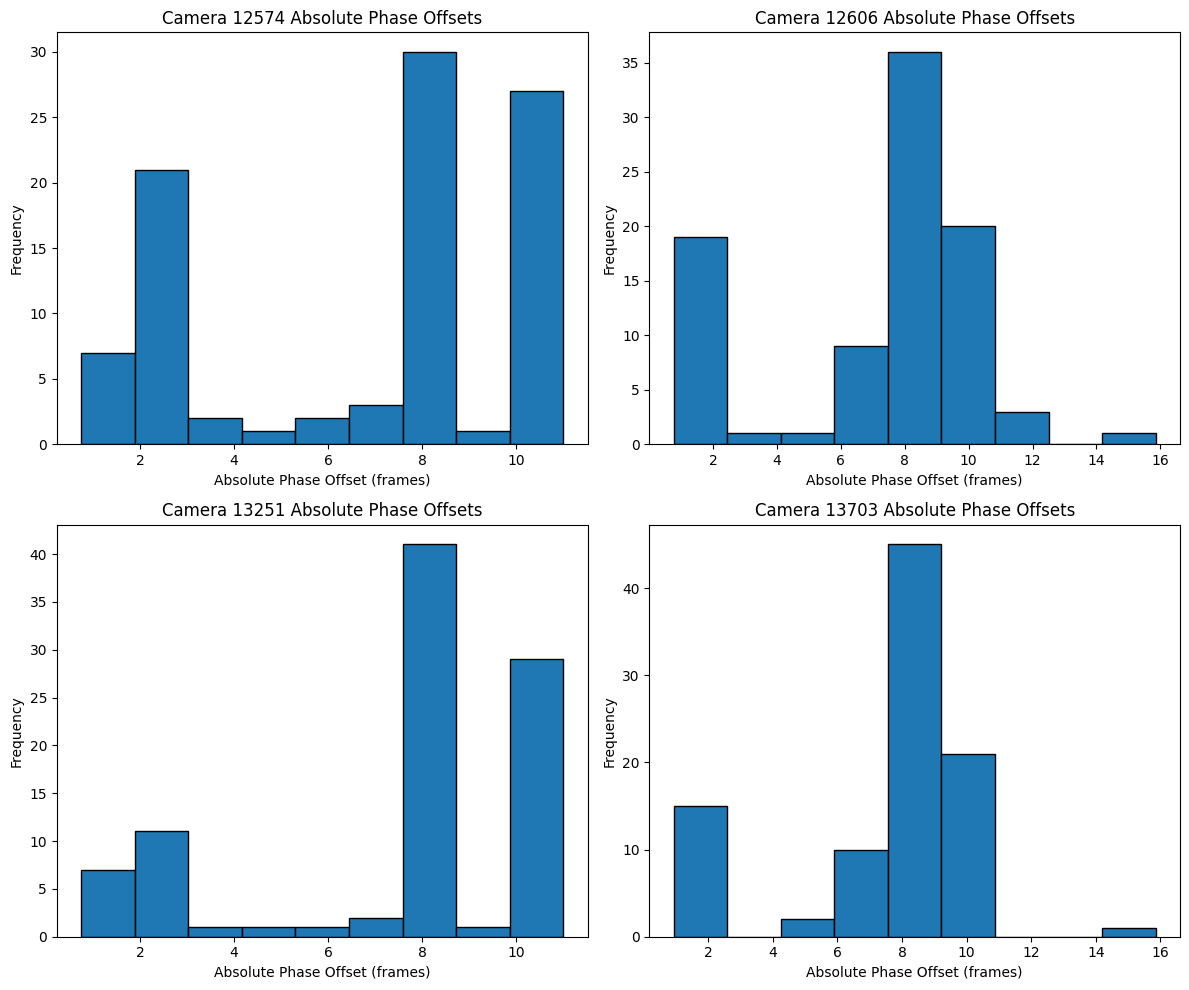

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].hist(df_12574["abs_phase_offset"], bins=int(np.sqrt(df_12574.shape[0])), edgecolor='black')
axs[0, 0].set_title("Camera 12574 Absolute Phase Offsets")
axs[0, 0].set_xlabel("Absolute Phase Offset (frames)")
axs[0, 0].set_ylabel("Frequency")

axs[0, 1].hist(df_12606["abs_phase_offset"], bins=int(np.sqrt(df_12606.shape[0])), edgecolor='black')
axs[0, 1].set_title("Camera 12606 Absolute Phase Offsets")
axs[0, 1].set_xlabel("Absolute Phase Offset (frames)")
axs[0, 1].set_ylabel("Frequency")

axs[1, 0].hist(df_13251["abs_phase_offset"], bins=int(np.sqrt(df_13251.shape[0])), edgecolor='black')
axs[1, 0].set_title("Camera 13251 Absolute Phase Offsets")
axs[1, 0].set_xlabel("Absolute Phase Offset (frames)")
axs[1, 0].set_ylabel("Frequency")

axs[1, 1].hist(df_13703["abs_phase_offset"], bins=int(np.sqrt(df_13703.shape[0])), edgecolor='black')
axs[1, 1].set_title("Camera 13703 Absolute Phase Offsets")
axs[1, 1].set_xlabel("Absolute Phase Offset (frames)")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("./fft_phase_analysis/5Hz/absolute_phase_offset_histograms.png", dpi=300)
plt.show()

In [15]:
pos_phase, neg_phase = 0, 0

for cam in [12574, 12606, 13251, 13703]:
    for idx, row in df.iterrows():
        if (row["main_camera"] == cam) or (row["other_camera"] == cam):
            if row["mu"] > 500:
                neg_phase += 1
            else:
                pos_phase += 1
    print(f"Camera {cam}: Positive Phase Count = {pos_phase}, Negative Phase Count = {neg_phase}")

Camera 12574: Positive Phase Count = 44, Negative Phase Count = 50
Camera 12606: Positive Phase Count = 86, Negative Phase Count = 98
Camera 13251: Positive Phase Count = 124, Negative Phase Count = 154
Camera 13703: Positive Phase Count = 170, Negative Phase Count = 202


In [34]:
df_first = df[df["file"] == "2026_03_24__17_20_25_cube.fits"]


# Define the conditions
conditions = [
    (df_first['mu'] < 30),
    (df_first['mu'] > 800)
]

# Assign which camera goes first based on the conditions
first_choices = [df_first['other_camera'], df_first['main_camera']]
second_choices = [df_first['main_camera'], df_first['other_camera']]

# Create the new columns
df_first['first_fired'] = np.select(conditions, first_choices, default='Unknown')
df_first['second_fired'] = np.select(conditions, second_choices, default='Unknown')

# Display the result
print(df_first[['mu', 'main_camera', 'other_camera', 'first_fired', 'second_fired']].head())


             mu  main_camera  other_camera first_fired second_fired
1      3.046664        12574         12606       12606        12574
32     0.794209        12574         13251       13251        12574
64   992.898951        12574         13703       12574        13703
95   989.132310        12606         13251       12606        13251
125    7.000969        12606         13703       13703        12606


In [39]:
import pandas as pd
import numpy as np

def calculate_global_firing_order(df):
    # 1. Apply your logic to identify which camera in the pair fired first
    # Based on your screenshot: 
    # If mu is low, the 'other_camera' is slightly ahead.
    # If mu is high, the 'main_camera' is significantly ahead in the cycle.
    conditions = [
        (df['mu'] < 500), # Using 500 as the midpoint for a binary decision
        (df['mu'] >= 500)
    ]
    first_choices = [df['other_camera'], df['main_camera']]
    
    df['winner'] = np.select(conditions, first_choices, default='Unknown')

    # 2. Count how many times each camera 'won' its comparison
    # A camera that fires earlier in the sequence will 'win' more often
    # against those that fire later.
    rankings = df['winner'].value_counts()
    
    # 3. Sort the cameras by the number of wins (Descending)
    firing_order = rankings.index.tolist()
    
    return firing_order


firing_order_dict = {
    "First": [],
    "Second": [],
    "Third": [],
    "Fourth": []
}


for file_name in df["file"].unique():
    df_file = df[df["file"] == file_name]
    
    # Define the conditions
    conditions = [
        (df_file['mu'] < 30),
        (df_file['mu'] > 800)
    ]

    # Assign which camera goes first based on the conditions
    first_choices = [df_file['other_camera'], df_file['main_camera']]
    second_choices = [df_file['main_camera'], df_file['other_camera']]

    # Create the new columns
    df_file['first_fired'] = np.select(conditions, first_choices, default='Unknown')
    df_file['second_fired'] = np.select(conditions, second_choices, default='Unknown')




    # Usage with your dataframe:
    order = calculate_global_firing_order(df_file)
    # print(f"The firing order is: {' -> '.join(map(str, order))}")
    if len(order) == 4:
        firing_order_dict["First"].append(order[0])
        firing_order_dict["Second"].append(order[1])
        firing_order_dict["Third"].append(order[2])
        firing_order_dict["Fourth"].append(order[3])
    else:
        print(f"Unexpected number of cameras in file {file_name}: {order}")
df_firing_order = pd.DataFrame(firing_order_dict)
print(df_firing_order)

Unexpected number of cameras in file 2026_04_09__17_45_51_cube.fits: ['12606', '13251', '12574']
Unexpected number of cameras in file 2026_04_09__17_55_19_cube.fits: ['12574', '13251', '13703']
Unexpected number of cameras in file 2026_03_24__17_15_57_cube.fits: ['12606', '13251', '13703']
Unexpected number of cameras in file 2026_03_24__17_22_00_cube.fits: ['12606', '13251', '13703']
Unexpected number of cameras in file 2026_03_24__17_26_58_cube.fits: ['12574', '12606', '13703']
Unexpected number of cameras in file 2026_03_24__17_14_54_cube.fits: ['13251', '12574', '13703']
Unexpected number of cameras in file 2026_03_24__17_17_33_cube.fits: ['12574', '12606', '13703']
Unexpected number of cameras in file 2026_03_24__17_27_47_cube.fits: ['12574', '12606', '13251']
Unexpected number of cameras in file 2026_04_09__17_53_22_cube.fits: ['12574', '13251']
Unexpected number of cameras in file 2026_04_09__17_54_20_cube.fits: ['12574', '13703', '13251']
    First Second  Third Fourth
0   1257

In [51]:
plt.figure(figsize=(8, 6))

print(df_firing_order["First"].value_counts())
print(df_firing_order["Second"].value_counts())
print(df_firing_order["Third"].value_counts())
print(df_firing_order["Fourth"].value_counts())

First
12606    10
12574     8
13251     4
Name: count, dtype: int64
Second
13703    14
13251     4
12574     3
12606     1
Name: count, dtype: int64
Third
12574    11
12606     5
13251     3
13703     3
Name: count, dtype: int64
Fourth
13251    11
12606     6
13703     5
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

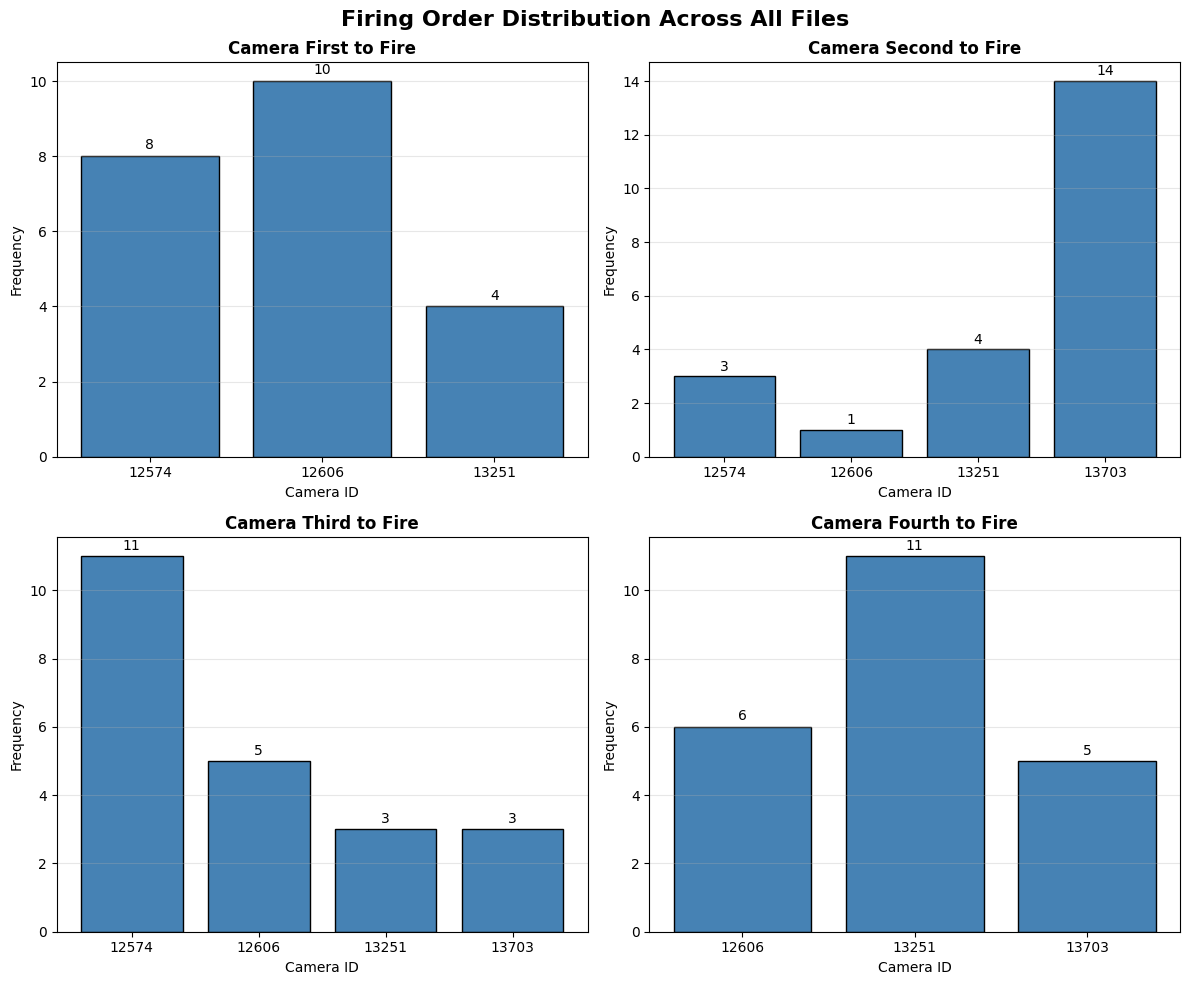

In [52]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Firing Order Distribution Across All Files", fontsize=16, fontweight='bold')

columns = ["First", "Second", "Third", "Fourth"]
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for col, (row, col_idx) in zip(columns, positions):
    counts = df_firing_order[col].value_counts().sort_index()
    ax = axs[row, col_idx]
    ax.bar(counts.index.astype(str), counts.values, edgecolor='black', color='steelblue')
    ax.set_title(f"Camera {col} to Fire", fontweight='bold')
    ax.set_xlabel("Camera ID")
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("./fft_phase_analysis/5Hz/firing_order_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
